In [1]:
import numpy as np
from tracklab import ExperimentReader
from configurations import create_fig, set_font_sizes, apply_general_styles
from scipy.stats import binom

apply_general_styles()
set_font_sizes(conf='tight')

In [24]:
def exact_fraction(V, K, L):
    total = 0.0
    for j in range(2, L):          # need at least 1 prior slot
        n_max = min(j-1, L-j)
        if n_max < 1:
            continue
        n_vals = np.arange(1, n_max+1)          # <-- changed from 2
        p_n = binom.pmf(n_vals, j-1, 1.0/V)
        m_max = (L - j) - n_vals
        p_m = binom.cdf(m_max, j-1-n_vals, (K-1)/(V-1))
        total += np.sum(p_n * p_m)
    return (K / (V * L)) * total



def softplus(x):
    return np.logaddexp(0.0, x)


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


def eff_loss(on_target_mean, on_target_var, off_target_var, V, K, approx=1, mc_samples=10_000):
    """
    Expected loss approximation.

    Parameters
    ----------
    approx : int
        1 : deterministic
        2 : deterministic + variance correction
        3 : moment-matched approximation
        4 : Monte Carlo
    """
    rho = K / V
    # Convert to numpy arrays if they are not already
    on_target_mean = np.asarray(on_target_mean)
    on_target_var = np.asarray(on_target_var)
    off_target_var = np.asarray(off_target_var)

    if approx == 1:
        L_trigg = np.log1p((V -1) * np.exp(-on_target_mean))

    elif approx == 2:
        L_trigg = np.log1p((V - 1) * np.exp(-on_target_mean + 0.5 * off_target_var))

    elif approx == 3:
        sigma_s2 = np.log1p((np.exp(off_target_var) - 1) / (V - 1))
        mu_s = np.log(V - 1) + 0.5 * (off_target_var - sigma_s2)

        mu_y = mu_s - on_target_mean
        tau2 = sigma_s2 + on_target_var

        s = sigmoid(mu_y)
        L_trigg = softplus(mu_y) + 0.5 * tau2 * s * (1.0 - s)

    elif approx == 4:

        B = len(on_target_mean)
        M = mc_samples

        on_logits = np.random.normal(
            loc=on_target_mean[:, None],
            scale=np.sqrt(on_target_var)[:, None],
            size=(B, M),
        )

        off_logits = np.random.normal(
            loc=0.0,
            scale=np.sqrt(off_target_var)[:, None, None],
            size=(B, M, V - 1),
        )

        S = np.exp(off_logits).sum(axis=-1)          # (B, M)

        loss = np.log1p(S * np.exp(-on_logits))      # (B, M)

        L_trigg = loss.mean(axis=1)                  # (B,)

    else:
        raise ValueError(f"Unknown approximation '{approx}'.")

    return L_trigg

In [27]:
experiment_name = 'refactored'
reader = ExperimentReader(experiment_name,base_dir='../data')
run_id = reader.list_runs()[-2]
data = reader.load_metrics(run_id)
cfg = reader.load_config(run_id)
# Pivot the data to have metrics as columns
data = data.pivot(index='step', columns='metric', values='value').reset_index()


print(f'Run ID: {run_id}')
# print(data.head())

rho = cfg['data_args']['rho']
K = cfg['data_args']['K']
alpha = cfg['model_args']['alpha_length']
V = cfg['model_args']['vocab_size']
L = cfg['model_args']['seq_len']
m = alpha/(1+rho)
# f = exact_fraction(V, K, L)
f = 0.9961*0.0267

print(f'Rho: {rho}, Vocab Size: {V}, Sequence Length: {L}, f: {f:.4f}')

Run ID: run_006
Rho: 0.2, Vocab Size: 512, Sequence Length: 230, f: 0.0266


In [ ]:
# COmpute effective losses:
losses = {}
for appx in [1,2,3,4]:
    print(f'Calculating effective loss with approximation {appx}...')
    L_trigg = eff_loss(data['on_logit_mean'], data['on_logit_var'], data['off_logit_var'], V, K, approx=appx)
    eff_loss_val = (1-f)*np.log(V) + f*L_trigg
    losses[appx] = eff_loss_val

Calculating effective loss with approximation 1...
Calculating effective loss with approximation 2...
Calculating effective loss with approximation 3...
Calculating effective loss with approximation 4...


(1000.0, 2000.0)

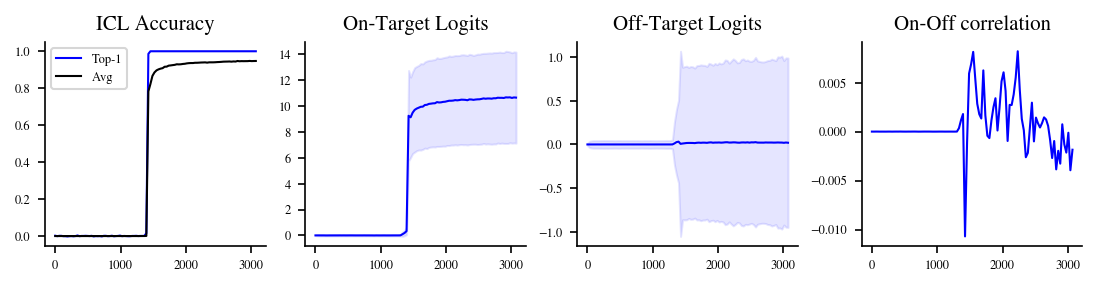

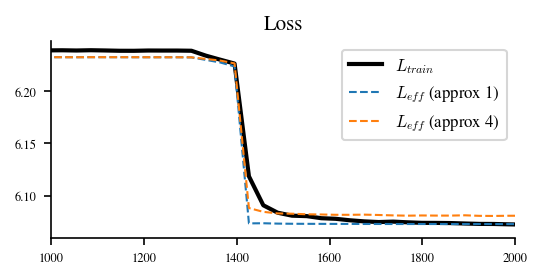

In [25]:
fig , axes = create_fig(ncols=4,size='double',h=0.25)

ax = axes[0]
ax.set_title(f'ICL Accuracy')
ax.plot(data['step'], data['top1_accuracy'], label='Top-1', color='blue')
ax.plot(data['step'], data['avg_accuracy'], label='Avg', color='black')
ax.legend()

ax = axes[1]
ax.set_title(f'On-Target Logits')
ax.plot(data['step'], data['on_logit_mean'], label='Mean', color='blue')
ax.fill_between(data['step'], 
                data['on_logit_mean'] - np.sqrt(data['on_logit_var']),
                data['on_logit_mean'] + np.sqrt(data['on_logit_var']),
                color='blue', alpha=0.1, label='Std Dev')

ax = axes[2]
ax.set_title(f'Off-Target Logits')
ax.plot(data['step'], data['off_logit_mean'], label='Mean', color='blue')
ax.fill_between(data['step'], 
                data['off_logit_mean'] - np.sqrt(data['off_logit_var']),
                data['off_logit_mean'] + np.sqrt(data['off_logit_var']),
                color='blue', alpha=0.1, label='Std Dev')

ax = axes[3]
ax.set_title(f'On-Off correlation')
ax.plot(data['step'], data['on_off_correlation'], label='Correlation', color='blue')  

fig , axes = create_fig()
ax = axes
ax.set_title(f'Loss')
# ax.axhline(np.log(V), color='red', linestyle='--')
# ax.axhline((1-f)*np.log(V), color='green', linestyle='--')
ax.plot(data['step'], data['loss'], label=r'$L_{train}$', color='black',lw=2)

for appx in [1,4]:
    eff_loss_val = losses[appx]
    ax.plot(data['step'], eff_loss_val, label=f'$L_{{eff}}$ (approx {appx})', ls='--')

ax.legend(fontsize=8)
ax.set_xlim(1000,2000)


In [ ]:
fig , axes = create_fig()
ax = axes
ax.set_title(f'Loss')
ax.axhline(np.log(V), color='red', linestyle='--')
ax.axhline((1-f)*np.log(V), color='green', linestyle='--')
ax.plot(data['step'], data['loss'], label=r'$L$', color='black')

for appx in [1,2,3,4]:
    print(f'Calculating effective loss with approximation {appx}...')
    L_trigg = eff_loss(data['on_logit_mean'], data['on_logit_var'], data['off_logit_var'], V, K, approx=appx)
    eff_loss_val = (1-f)*np.log(V) + f*L_trigg
    ax.plot(data['step'], eff_loss_val, label=f'$L_{{eff}}$ (approx {appx})', ls='--')

ax.legend();